In [ ]:
%pip install pandas matplotlib openpyxl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

xls= pd.ExcelFile("DecodeLabs_Project1_Cleaned.xlsx")
print(xls.sheet_names)

df = pd.read_excel(xls, sheet_name=1)
print(df.shape)
print(df.columns.tolist())
df.head()

['Sheet1', 'Sheet2', 'Change Log', 'Sheet3']
(466, 15)
['OrderID', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Date', 'TotalSales']


,OrderID,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Date,TotalSales
0,ORD200000,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023-01-04,2853.10
1,ORD200001,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024-08-23,302.70
2,ORD200004,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025-05-08,2504.04
3,ORD200005,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72,2023-10-23,491.72
4,ORD200007,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75,2023-05-12,747.75


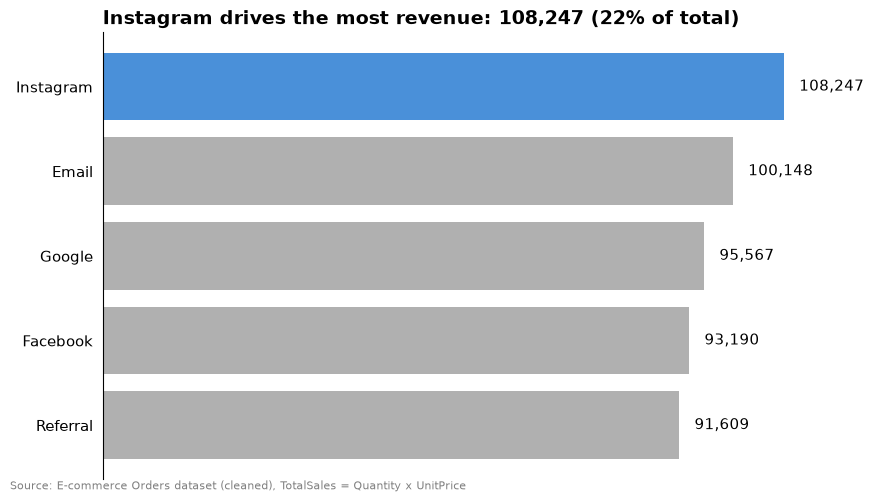

In [4]:
if "TotalSales" not in df.columns:
    df["TotalSales"] =df["Quantity"]* df["unitPrice"]
    # Make sure TotalSales exists


# Revenue by referral source, sorted high to low
rev = df.groupby("ReferralSource")["TotalSales"].sum().sort_values()
total = rev.sum()
top = rev.index[-1]
share = rev.iloc[-1] / total * 100

# Grey bars, one blue highlight on the top source
colors = ["#4A90D9" if s == top else "#B0B0B0" for s in rev.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(rev.index, rev.values, color=colors)

# Direct labels instead of a legend
for bar, val in zip(bars, rev.values):
    ax.text(val + total * 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}", va="center", fontsize=11)

# Action title: states the conclusion
ax.set_title(f"{top} drives the most revenue: {rev.iloc[-1]:,.0f} ({share:.0f}% of total)",
             loc="left", fontsize=14, fontweight="bold")

# Remove chartjunk
ax.set_xlim(0, rev.max() * 1.15)
ax.set_xticks([])
for side in ["top", "right", "bottom"]:
    ax.spines[side].set_visible(False)
ax.tick_params(left=False, labelsize=11)

# Footnote
fig.text(0.01, 0.01, "Source: E-commerce Orders dataset (cleaned), TotalSales = Quantity x UnitPrice",
         fontsize=8, color="gray")

plt.tight_layout()
plt.savefig("chart1_referral_revenue.png", dpi=200)
plt.show()

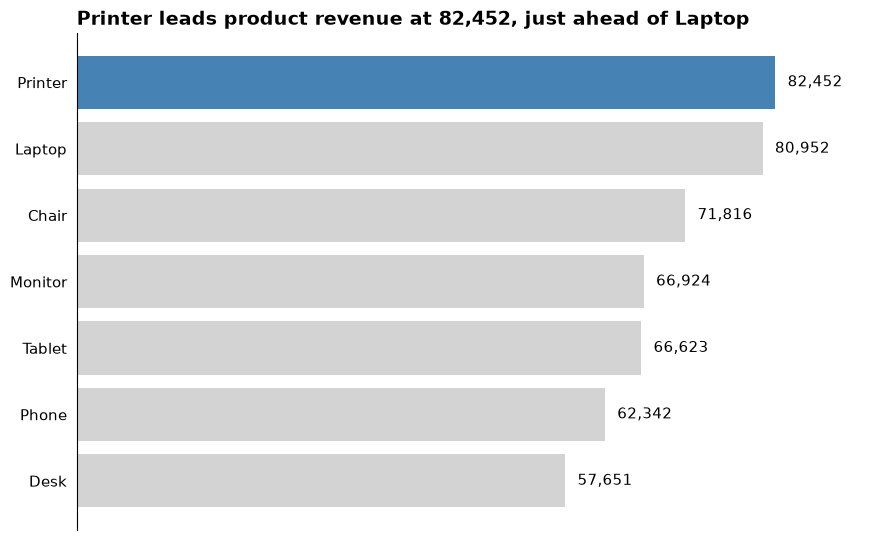

In [17]:
rev2 = df.groupby("Product")["TotalSales"].sum().sort_values()
total2 = rev2.sum()
top = rev2.index[-1]
second = rev2.index[-2]

colors = ["steelblue" if p == top else "lightgrey" for p in rev2.index]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(rev2.index, rev2.values, color=colors)

for bar, val in zip(bars, rev2.values):
    ax.text(val + total2 * 0.003, bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}", va="center", fontsize=11)

ax.set_title(f"{top} leads product revenue at {rev2.iloc[-1]:,.0f}, just ahead of {second}",
             loc="left", fontsize=14, fontweight="bold")

ax.set_xlim(0, rev2.max() * 1.15)
ax.set_xticks([])
for side in ["top", "right", "bottom"]:
    ax.spines[side].set_visible(False)
ax.tick_params(left=False, labelsize=11)

plt.tight_layout()
plt.savefig("chart2_product_revenue.png", dpi=200)
plt.show()

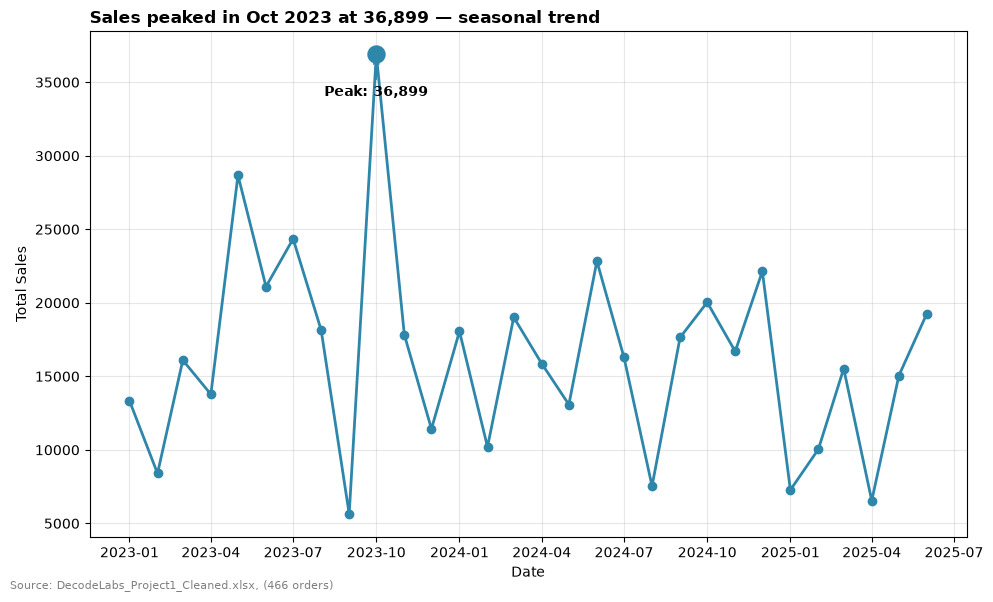

Peak is 2023-10-01 00:00:00 = 36899.08


In [25]:
plt.figure(figsize=(10,6))

# Fix Date
df['Date'] = pd.to_datetime(df['Date'])

# Group by month properly
monthly_sales = df.groupby(df['Date'].dt.to_period('M')).sum(numeric_only=True)['TotalSales']
monthly_sales.index = monthly_sales.index.to_timestamp()

# Plot full line
plt.plot(monthly_sales.index, monthly_sales.values, 
         marker='o', color='#2E86AB', linewidth=2)

# Find peak for title
peak_date = monthly_sales.idxmax()
peak_val = monthly_sales.max()

plt.title(f'Sales peaked in {peak_date.strftime("%b %Y")} at {peak_val:,.0f} — seasonal trend', 
          fontweight='bold', loc='left', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(alpha=0.3)
plt.xticks(rotation=0)

# Spotlight peak
plt.scatter([peak_date], [peak_val], color='#2E86AB', s=150, zorder=5)
plt.annotate(f'Peak: {peak_val:,.0f}', xy=(peak_date, peak_val),
             xytext=(0,-30), textcoords='offset points',
             ha='center', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#2E86AB'))

plt.tight_layout()
plt.figtext(0.01, 0.01, "Source: DecodeLabs_Project1_Cleaned.xlsx, (466 orders)", fontsize=8, color='gray')
plt.savefig("chart3_monthly_sales.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Peak is {peak_date} = {peak_val}")

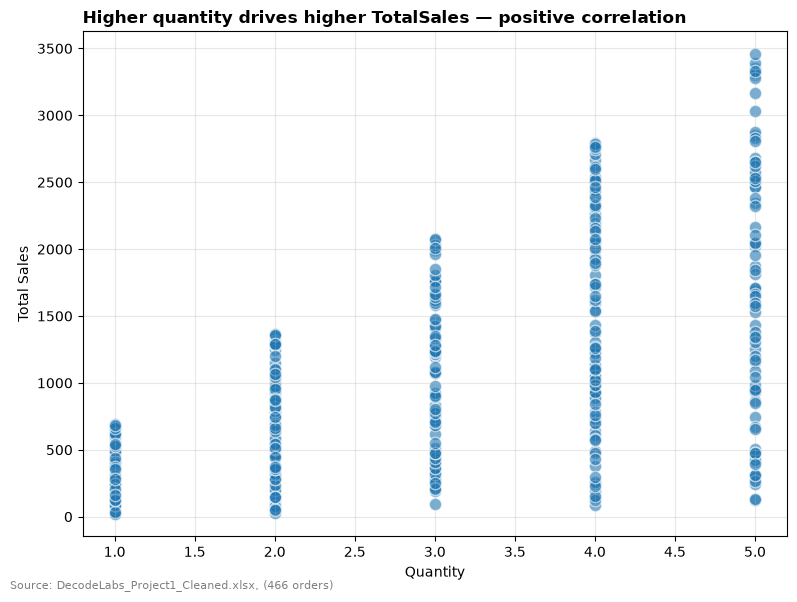

In [22]:
plt.figure(figsize=(8,6))

# Scatter: Quantity vs TotalSales, colored by Product
# Using your columns: Quantity and TotalSales
plt.scatter(df['Quantity'], df['TotalSales'], alpha=0.6, edgecolors='w', s=80)

plt.title('Higher quantity drives higher TotalSales — positive correlation', fontsize=12, fontweight='bold', loc='left')
plt.xlabel('Quantity')
plt.ylabel('Total Sales')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.figtext(0.01, 0.01, "Source: DecodeLabs_Project1_Cleaned.xlsx, (466 orders)", fontsize=8, color="gray")

plt.savefig("chart4_quantity_vs_sales.png", dpi=200, bbox_inches='tight')
plt.show()